# K-means Clustering (NBA)

K-means is a popular technique used to find groups of similar points in a dataset. It is especially useful when working with higher dimensional data.

**The Algorithm** 
- Select K number of clusters
- randomly select k distinct data points
- measure distance b/w points and the cluster centers and assign to the cluster they’re closest to
- repeat until it finds the cluster setup that maximizes within cluster variation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('nba_2013.csv')

In [3]:
df.shape

(481, 31)

In [4]:
df.sort_values('pts',ascending=False).head()

,player,pos,age,bref_team_id,g,gs,mp,fg,fga,fg.,...,drb,trb,ast,stl,blk,tov,pf,pts,season,season_end
133,Kevin Durant,SF,25,OKC,81,81,3122,849,1688,0.503,...,540,598,445,103,59,285,174,2593,2013-2014,2013
17,Carmelo Anthony,PF,29,NYK,77,77,2982,743,1643,0.452,...,477,622,242,95,51,198,224,2112,2013-2014,2013
225,LeBron James,PF,29,MIA,77,77,2902,767,1353,0.567,...,452,533,488,121,26,270,126,2089,2013-2014,2013
277,Kevin Love,PF,25,MIN,77,77,2797,650,1421,0.457,...,739,963,341,59,35,196,136,2010,2013-2014,2013
179,Blake Griffin,PF,24,LAC,80,80,2863,718,1359,0.528,...,565,757,309,92,51,224,265,1930,2013-2014,2013


## Point guards

Point guards play one of the most crucial roles on a team because their primary responsibility is to create scoring opportunities for the team. We are going to focus our lesson on a machine learning technique called clustering, which allows us to visualize the types of point guards as well as group similar point guards together. Using 2 features allows us to easily visualize the players and will also make it easier to grasp how clustering works. For point guards, it's widely accepted that the Assist to Turnover Ratio is a good indicator for performance in games as it quantifies the number of scoring opportunities that player created. Let's also use Points Per Game, since effective Point Guards not only set up scoring opportunities but also take a lot of the shots themselves.

- Create a new Dataframe which contains just the point guards from the data set.
    - Point guards are specified as PG in the pos column.
    - Assign the filtered data frame to point_guards.

In [5]:
pg = df[df['pos']=='PG']

In [6]:
## Add a PPG feature

pg['ppg'] = pg['pts']/pg['g']
pg[['player','pts','g','ppg']].sort_values('ppg',ascending=False).head()

/Users/wynnephilpott/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


,player,pts,g,ppg
110,Stephen Curry,1873,78,24.012821
459,Russell Westbrook,1002,46,21.782609
218,Kyrie Irving,1478,71,20.816901
272,Damian Lillard,1695,82,20.670732
423,Isaiah Thomas,1465,72,20.347222


Add an Assist Turnover Ratio, which is calculated by dividing total assists (ast) by total turnovers (tov):

In [7]:
pg = pg[pg['tov']!=0]

pg['atr'] = pg['ast']/pg['tov']
pg.sort_values('atr').head()

,player,pos,age,bref_team_id,g,gs,mp,fg,fga,fg.,...,ast,stl,blk,tov,pf,pts,season,season_end,ppg,atr
60,Avery Bradley,PG,23,BOS,60,58,1855,361,825,0.438,...,85,63,11,96,145,891,2013-2014,2013,14.850000,0.885417
76,Dwight Buycks,PG,24,TOR,14,0,146,15,48,0.313,...,10,8,0,10,11,43,2013-2014,2013,3.071429,1.000000
82,Isaiah Canaan,PG,22,HOU,22,0,252,31,87,0.356,...,22,8,4,21,25,101,2013-2014,2013,4.590909,1.047619
415,Tyshawn Taylor,PG,23,BRK,23,3,270,31,91,0.341,...,36,12,1,31,29,89,2013-2014,2013,3.869565,1.161290
375,Derrick Rose,PG,25,CHI,10,10,311,58,164,0.354,...,43,5,1,34,15,159,2013-2014,2013,15.900000,1.264706


## Plot PPG and ATR

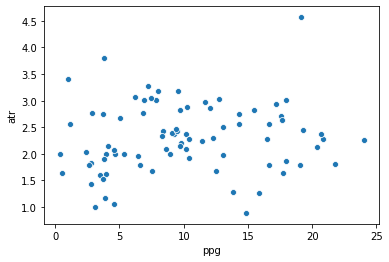

In [8]:
sns.scatterplot('ppg', 'atr',data=pg)

There seem to be 3 general regions, or clusters, that the point guards fall into (with a few outliers of course!). We can use a technique called clustering to segment all of the point guards into groups of alike players. While regression and other supervised machine learning techniques work well when we have a clear metric we want to optimize for and lots of pre-labelled data, we need to instead use unsupervised machine learning techniques to explore the structure within a data set that doesn't have a clear value to optimize.

There are multiple ways of clustering data but here we will focus on centroid based clustering for this lesson. Centroid based clustering works well when the clusters resemble circles with centers (or centroids). The centroid represent the arithmetic mean of all of the data points in that cluster.

K-Means Clustering is a popular centroid-based clustering algorithm that we will use. The K in K-Means refers to the number of clusters we want to segment our data into. The key part with K-Means (and most unsupervised machine learning techniques) is that we have to specify what k is. There are advantages and disadvantages to this, but one advantage is that we can pick the k that makes the most sense for our use case. We'll set k to 3 since we want K-Means to segment our data into 3 clusters.

## K-means Cluster Build

### Elbow Method

The elbow method is a useful graphical tool to estimate the optimal number of clusters k for a given task. Intuitively, we can say that, if k increases, the within-cluster SSE will decrease. This is because the samples will be closer to the centroids they are assigned to.

The idea behind the elbow method is to identify the value of k where the SSE stops decreasing rapidly, which will become clearer if we plot the SSE for different values of k:

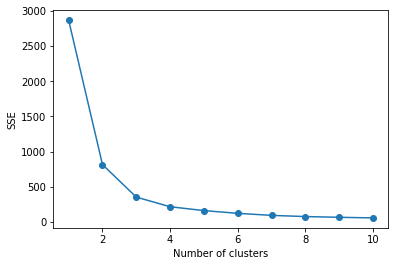

In [9]:
from sklearn.cluster import KMeans

distortions = []
for i in range(1, 11):
    km = KMeans(
        n_clusters=i, init='random',
        n_init=10, max_iter=300,
        tol=1e-04, random_state=0
    )
    km.fit(pg[['ppg','atr']])
    distortions.append(km.inertia_)

# plot
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

It appears to "elbow" at k=3.

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(pg[['ppg','atr']])

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [11]:
kmeans.cluster_centers_

array([[ 3.60167604,  2.0586095 ],
       [17.81259557,  2.28987786],
       [ 9.75908907,  2.49887835]])

In [12]:
kmeans.labels_

array([2, 2, 2, 2, 2, 1, 1, 2, 2, 0, 2, 0, 1, 2, 0, 2, 1, 1, 0, 1, 2, 2,
       0, 0, 2, 2, 2, 1, 1, 2, 2, 0, 1, 1, 0, 1, 1, 2, 2, 1, 0, 2, 2, 0,
       0, 0, 2, 0, 0, 2, 2, 1, 0, 1, 1, 0, 0, 0, 2, 2, 2, 1, 2, 0, 2, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 2, 2, 2], dtype=int32)

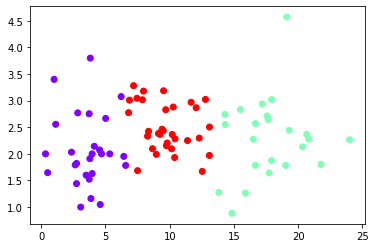

In [13]:
plt.scatter('ppg', 'atr',data=pg,c=kmeans.labels_,cmap='rainbow')

In [14]:
## Add cluster label to dataframe
pg = pg.reset_index(drop=True)
pg['cluster'] = pd.Series(kmeans.labels_)
pg.sort_values('ppg',ascending=False).head(10)[['player','cluster']]

,player,cluster
17,Stephen Curry,1
77,Russell Westbrook,1
28,Kyrie Irving,1
36,Damian Lillard,1
70,Isaiah Thomas,1
73,John Wall,1
54,Chris Paul,1
19,Monta Ellis,1
39,Kyle Lowry,1
33,Brandon Knight,1


- We can see that the best players indeed cluster together